# Seminar 4: Neural Networks

## 0. Description
This project aims to predict domestic Wi-Fi network performance using a neural network model. Given some network characteristics such as connection location (`LocationNumber`), signal strength (`RSSI`), link speeds (`TxLinkSpeed`, `RxLinkSpeed`) and connection type (`MainAPConnect`), the model estimates the throughtput and the average latency, which are provided as ground truth in the dataset.

| Type    | Column Name       | Description                                                                 |
|---------|-------------------|-----------------------------------------------------------------------------|
| Feature | `LocationNumber`  | Zone number where the data was collected (up to 35 different zones).        |
| Feature | `RSSI`            | Signal strength at the measurement point (Received Signal Strength Indicator). |
| Feature | `TxLinkSpeed`     | Downlink speed (from the access point to the client).                       |
| Feature | `RxLinkSpeed`     | Uplink speed (from the client to the access point).                         |
| Feature | `MainAPConnect`   | Binary value: 1 if the client is connected to the main access point, 0 if connected to an extender. |
| Label   | `TxThroughput`    | Actual throughput achieved by the Wi-Fi network.                            |
| Label   | `AvgPingLatency`  | Average latency measured via ping tests to a server.                        |

## 1. Part I: Data analysis

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [5]:
df = pd.read_csv("dataset_Seminar4/train_data.csv")

In [6]:
df.head()

,LocationNumber,RSSI,TxLinkSpeed,RxLinkSpeed,MainAPConnect,TxThroughput,AvgPingLatency
0,2,-72.32,163.11,118.36,1,13.51,51.79
1,32,-73.18,238.45,212.83,1,3.35,68.80
2,20,-40.67,865.44,863.39,1,17.62,50.79
3,10,-60.66,473.89,396.92,1,14.30,64.15
4,29,-67.96,479.74,355.99,1,4.81,73.81


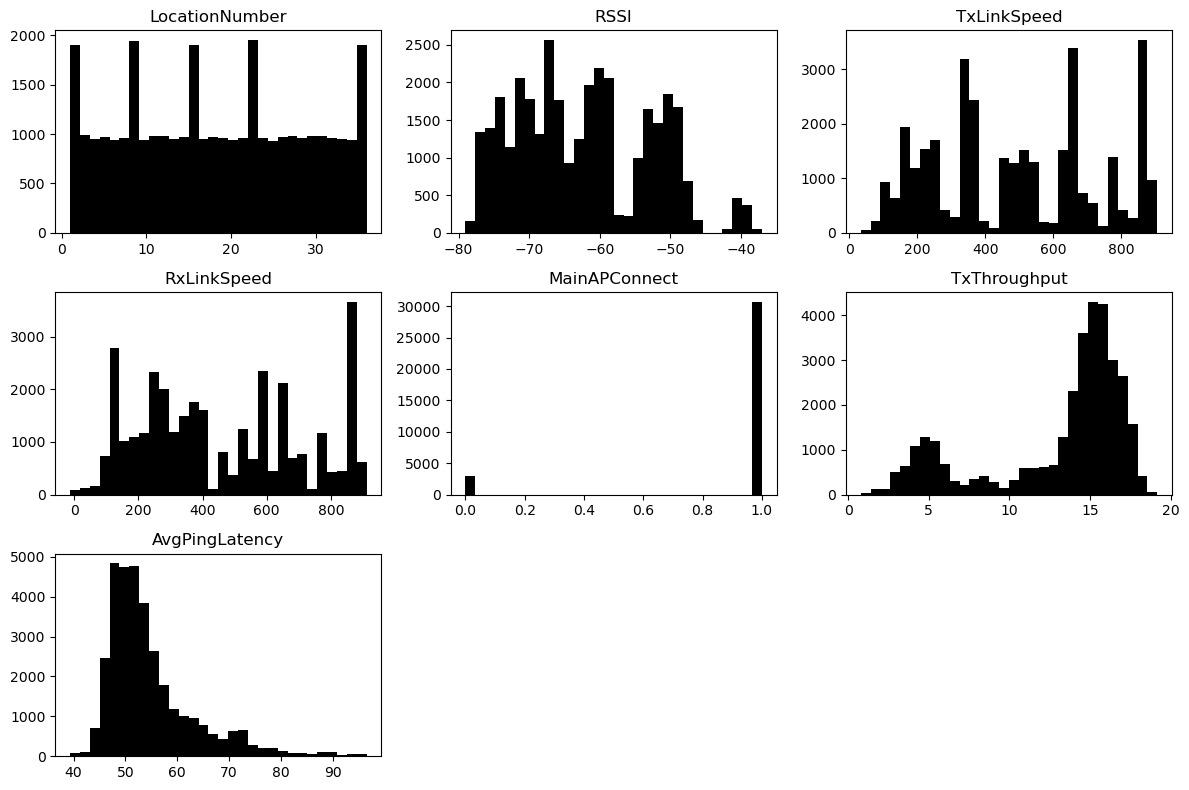

In [7]:
df.hist(bins=30, figsize=(12, 8), color="black", grid=False)

plt.tight_layout()
plt.show()

Let’s look at the histogram of each column in the dataset:

- The values of `RSSI` are mostly between -70 and -50 dBm, which suggests that the signal strength is between fair and good.  
- For `TxLinkSpeed` and `RxLinkSpeed`, we see that the values vary, but they only take a limited set of fixed values. This might be due to hardware constraints. It also means the variable is not truly continuous, which could affect the model’s performance.  
- `MainAPConnect` is a binary variable that is mostly `1`. This imbalance could introduce bias into the model, so it needs to be handled properly.  
- For the first ground truth, `TxThroughput`, the distribution is skewed. This means the model will need to learn to predict both high and low throughput cases.  
- Finally, `AvgPingLatency` is mostly grouped between 45 and 60 ms, with a long tail.

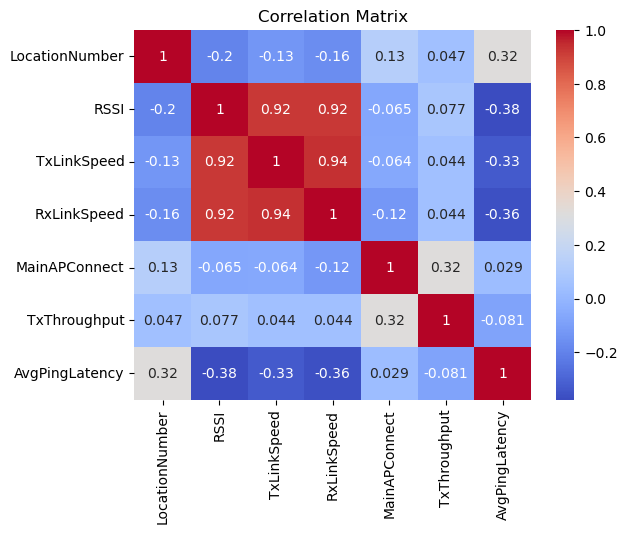

In [9]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')

plt.title("Correlation Matrix")
plt.show()

About the correlation matrix, it can see that `RSSI`, `TxLinkSpeed` and `RxLinkSpeed` are strongly correlated between them (> 0.9), which indicate a redundant information between those variables. But none of the parameters has correlation with the ground truth (`TxThroughout` and `AvgPingLatency`).

Furthermore, `AvgPingLatency` tends to has a negative correlation with `RSSI` and link velocities, which confirm that weak signals and low speeds generate more latency.

## 2. Part II: Neural Network Model

In this part, the relevant features to predict the `TxThroughput` y `AvgPingLatency` are selected. Based on the correlation analysis, the chosen features are: `RSSI`, `TxLinkSpeed`, `RxLinkSpeed` and `MainAPConnect`, since they do not present a high correlation and add variability to the model. On the other hand, `LocationNumber` does not provide relevant information and may be excluded.

### 2.1. Feature selection

In [14]:
# Select features and targets
features = df[['RSSI', 'TxLinkSpeed', 'RxLinkSpeed', 'MainAPConnect']]
labels = df[['TxThroughput', 'AvgPingLatency']]

### 2.2. Preprocessing

In [16]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [17]:
# Normalize features
x_scaler = StandardScaler()
X_features = x_scaler.fit_transform(features)

y_scaler = StandardScaler()
y_labels = y_scaler.fit_transform(labels.values)

In [18]:
# Split data
X_train, X_val, y_train, y_val = train_test_split(X_features, y_labels, test_size=0.2, random_state=42)

### 2.3. FNN Model

For this project, Feedforward Neural Network (FNN) is used as a model to predict the performance of the Wi-Fi network. This model processes input data through a fully connected layers, which adjust their weights in order to minimize the error in each iteration.
FNNs is useful for capturing non-linear relationships between features and target outputs, and capture complex relations.

![FNN Architecture](https://www.researchgate.net/publication/358760958/figure/fig2/AS:1171042303254529@1656209650682/The-feed-forward-neural-network-FNN-architecture-employed-in-this-study.png)

In [21]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [22]:
# Model
model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(256, activation='relu'),
    Dropout(0.2),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dense(2, activation='linear')
])

In [23]:
# Compile
model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='mse',
    metrics=['mae']
)

This FNN model is using three hidden layers of 256, 128, and 64 neurons respectively, with ReLU activation. Technique Dropout layers helps us to reduce overfitting, randomly deactivating some neurons during training. And the output layer uses a linear activation to predict the two target variables.

### 2.4. Training

In [26]:
# Training
history = model.fit(X_train, y_train,
                    validation_data=(X_val, y_val),
                    epochs=200,
                    batch_size=32,
                    verbose=1)

Epoch 1/200
840/840 ━━━━━━━━━━━━━━━━━━━━ 1s 502us/step - loss: 0.8621 - mae: 0.7077 - val_loss: 0.7933 - val_mae: 0.6736
Epoch 2/200
840/840 ━━━━━━━━━━━━━━━━━━━━ 0s 468us/step - loss: 0.7800 - mae: 0.6665 - val_loss: 0.7675 - val_mae: 0.6649
Epoch 3/200
840/840 ━━━━━━━━━━━━━━━━━━━━ 0s 449us/step - loss: 0.7532 - mae: 0.6532 - val_loss: 0.7491 - val_mae: 0.6476
Epoch 4/200
840/840 ━━━━━━━━━━━━━━━━━━━━ 0s 451us/step - loss: 0.7378 - mae: 0.6486 - val_loss: 0.7319 - val_mae: 0.6435
Epoch 5/200
840/840 ━━━━━━━━━━━━━━━━━━━━ 0s 448us/step - loss: 0.7244 - mae: 0.6397 - val_loss: 0.7240 - val_mae: 0.6386
Epoch 6/200
840/840 ━━━━━━━━━━━━━━━━━━━━ 0s 450us/step - loss: 0.7168 - mae: 0.6381 - val_loss: 0.7190 - val_mae: 0.6396
Epoch 7/200
840/840 ━━━━━━━━━━━━━━━━━━━━ 0s 453us/step - loss: 0.7164 - mae: 0.6364 - val_loss: 0.7119 - val_mae: 0.6360
Epoch 8/200
840/840 ━━━━━━━━━━━━━━━━━━━━ 0s 447us/step - loss: 0.7101 - mae: 0.6350 - val_loss: 0.7036 - val_mae: 0.6280
Epoch 9/200
840/840 ━━━━━━━━━━━━

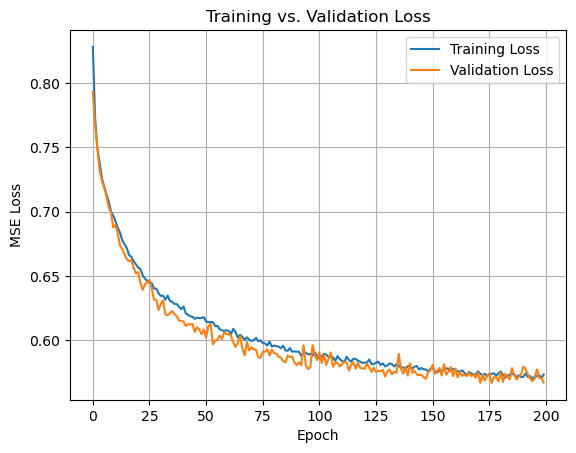

In [27]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.title("Training vs. Validation Loss")
plt.grid(True)
plt.show()

The graph represents the evolution of the mean square error (MSE Loss) with respect to the training and validation sets. Both are observed to decrease steadily, indicating that the model is learning. The fluctuations are natural in the validation model, as it may present greater variability than the trained data. Both evolutions closely follow each other, indicating that the model generalizes well and there is no overfitting.

## 2.5. Evaluate

In [30]:
df_test = pd.read_csv("dataset_Seminar4/test_data.csv")

In [31]:
df_test.head()

,LocationNumber,RSSI,TxLinkSpeed,RxLinkSpeed,MainAPConnect,TxThroughput,AvgPingLatency
0,16,-53.19,787.51,653.48,1,15.94,56.30
1,24,-62.79,657.90,592.37,1,17.31,49.78
2,34,-71.16,259.18,178.29,0,2.89,55.83
3,28,-63.99,467.56,375.04,1,17.01,85.71
4,6,-69.29,355.26,313.15,1,14.05,59.40


In [32]:
# Split test set
X_test_raw = df_test[features.columns]
X_test = x_scaler.transform(X_test_raw)
y_test = df_test[['TxThroughput', 'AvgPingLatency']].values

In [38]:
# Prediction
y_pred = model.predict(X_test)

y_pred_real = y_scaler.inverse_transform(y_pred)

263/263 ━━━━━━━━━━━━━━━━━━━━ 0s 215us/step


In [49]:
# Metrics
mse = mean_squared_error(y_test, y_pred_real)
mae = mean_absolute_error(y_test, y_pred_real)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_real)

print(f"MAE:  {mae:.2f}")
print(f"MSE:  {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²:   {r2:.2f}")

MAE:  3.45
MSE:  24.70
RMSE: 4.97
R²:   0.43


The mean absolute error (`MAE = 3.45`) indicates that the average deviation is `3.45%` from the actual value. On the other hand, `MSE = 24.70` penalizes large errors more, and `RMSE = 4.97`, its square root, provides an estimate of the standard error, confirming the model's stable behavior in correctly predicting. `R² = 0.43` indicates that the model captures `43%` of the data variability; while it is not perfect, it reflects the path to follow to learn relevant patterns in the test set.

## 2.6. Conclusions

As a next step to improve the model, we could focus on training separate models for each target variable instead of using a single multi-output network. Since `TxThroughput` and `AvgPingLatency` represent different aspects of network performance and may depend on the input features in distinct ways, using one model per target could allow each network to specialize and learn more accurately. This approach would also allow for customized architectures, loss functions, and training strategies for each variable, potentially leading to better overall performance.